In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import kagglehub as kh
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

pio.templates.default = 'plotly_white'

**Note**: To make `competition_download` to work you need to store the `~/.kaggle/access_token` first!

In [2]:
path = kh.competition_download('new-york-city-taxi-fare-prediction')
data_path = Path(path)
data_path

PosixPath('/Users/shmuma/.cache/kagglehub/competitions/new-york-city-taxi-fare-prediction')

In [3]:
TRAIN_PATH = data_path / "train.csv"
TRAIN_PATH.stat().st_size

5697178298

# Memory efficient representation

If we load 55M rows into memory using pandas, it will take ~9GB, which might be too much.
Let's optimize it a bit.

In [4]:
%%time
# load 1M rows first
df = pd.read_csv(TRAIN_PATH, nrows=1000000)

CPU times: user 812 ms, sys: 49.8 ms, total: 862 ms
Wall time: 865 ms


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   key                1000000 non-null  str    
 1   fare_amount        1000000 non-null  float64
 2   pickup_datetime    1000000 non-null  str    
 3   pickup_longitude   1000000 non-null  float64
 4   pickup_latitude    1000000 non-null  float64
 5   dropoff_longitude  999990 non-null   float64
 6   dropoff_latitude   999990 non-null   float64
 7   passenger_count    1000000 non-null  int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 109.4 MB


In [6]:
df.memory_usage(deep=True)

Index                     132
key                  35676793
fare_amount           8000000
pickup_datetime      31000000
pickup_longitude      8000000
pickup_latitude       8000000
dropoff_longitude     8000000
dropoff_latitude      8000000
passenger_count       8000000
dtype: int64

In [7]:
print(df[['key', 'pickup_datetime']].head())

                             key          pickup_datetime
0    2009-06-15 17:26:21.0000001  2009-06-15 17:26:21 UTC
1    2010-01-05 16:52:16.0000002  2010-01-05 16:52:16 UTC
2   2011-08-18 00:35:00.00000049  2011-08-18 00:35:00 UTC
3    2012-04-21 04:30:42.0000001  2012-04-21 04:30:42 UTC
4  2010-03-09 07:51:00.000000135  2010-03-09 07:51:00 UTC


In [8]:
sys.getsizeof(df.pickup_datetime), sys.getsizeof(df.key)

(31000164, 35676957)

In [9]:
%%time
df2 = pd.read_csv(TRAIN_PATH, nrows=1000000, parse_dates=['pickup_datetime'], usecols=range(1, 8))

CPU times: user 5.5 s, sys: 110 ms, total: 5.61 s
Wall time: 5.62 s


In [10]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column             Non-Null Count    Dtype              
---  ------             --------------    -----              
 0   fare_amount        1000000 non-null  float64            
 1   pickup_datetime    1000000 non-null  datetime64[us, UTC]
 2   pickup_longitude   1000000 non-null  float64            
 3   pickup_latitude    1000000 non-null  float64            
 4   dropoff_longitude  999990 non-null   float64            
 5   dropoff_latitude   999990 non-null   float64            
 6   passenger_count    1000000 non-null  int64              
dtypes: datetime64[us, UTC](1), float64(5), int64(1)
memory usage: 53.4 MB


In [11]:
sys.getsizeof(df2)

56000164

In [12]:
sys.getsizeof(df2.pickup_datetime)

8000164

## Use pyarrow

In [13]:
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.dataset as ds

In [14]:
data = ds.dataset(TRAIN_PATH, format="csv")

In [15]:
%%time
data.count_rows()

CPU times: user 4.02 s, sys: 860 ms, total: 4.88 s
Wall time: 4.09 s


55423856

In [16]:
table_1m = data.head(1_000_000)
sys.getsizeof(table_1m)

83023026

In [17]:
table_1m.schema

key: timestamp[ns]
fare_amount: double
pickup_datetime: string
pickup_longitude: double
pickup_latitude: double
dropoff_longitude: double
dropoff_latitude: double
passenger_count: int64

In [18]:
col = table_1m['passenger_count']
print(type(col))
print(len(col))
print(len(col.chunks))

<class 'pyarrow.lib.ChunkedArray'>
1000000
99


In [19]:
sys.getsizeof(col)

8000088

In [20]:
table = data.head(1_000_000, columns={
    'passenger_count': ds.field('passenger_count').cast(pa.uint8()),
})
print(table.schema)
print(sys.getsizeof(table['passenger_count']))

passenger_count: uint8
1000088


In [21]:
def parse_datetime(expr: pc.Expression) -> pc.Expression:
    return pc.strptime(pc.replace_substring(expr, " UTC", ""),
                       format="%Y-%m-%d %H:%M:%S", unit='s')

In [22]:
table_1m = data.head(1_000_000, columns={
    'pickup_datetime': parse_datetime(ds.field('pickup_datetime')),
    'fare_amount': ds.field('fare_amount').cast(pa.float32()),
    'pickup_longitude': ds.field('pickup_longitude').cast(pa.float32()),
    'pickup_latitude': ds.field('pickup_latitude').cast(pa.float32()),
    'dropoff_longitude': ds.field('dropoff_longitude').cast(pa.float32()),
    'dropoff_latitude': ds.field('dropoff_latitude').cast(pa.float32()),
    'passenger_count': ds.field('passenger_count').cast(pa.uint8()),
})
table_1m.schema

pickup_datetime: timestamp[s]
fare_amount: float
pickup_longitude: float
pickup_latitude: float
dropoff_longitude: float
dropoff_latitude: float
passenger_count: uint8

In [23]:
sys.getsizeof(table_1m)

29148073

In [24]:
table_full = data.to_table(columns={
    'pickup_datetime': parse_datetime(ds.field('pickup_datetime')),
    'fare_amount': ds.field('fare_amount').cast(pa.float32()),
    'pickup_longitude': ds.field('pickup_longitude').cast(pa.float32()),
    'pickup_latitude': ds.field('pickup_latitude').cast(pa.float32()),
    'dropoff_longitude': ds.field('dropoff_longitude').cast(pa.float32()),
    'dropoff_latitude': ds.field('dropoff_latitude').cast(pa.float32()),
    'passenger_count': ds.field('passenger_count').cast(pa.uint8()),
})
sys.getsizeof(table_full)

1615138057

# Column data anomalies

In [25]:
for col in table_full.column_names:
    nulls_cnt = pc.sum(pc.is_null(table_full[col]))
    min_max = pc.min_max(table_full[col], skip_nulls=True)
    print(f"{col:25}nulls={str(nulls_cnt)}\n"
          f"min={str(min_max['min']):20} max={min_max['max']}\n")

pickup_datetime          nulls=0
min=2009-01-01 00:00:27  max=2015-06-30 23:59:54

fare_amount              nulls=0
min=-300.0               max=93963.359375

pickup_longitude         nulls=0
min=-3442.0595703125     max=3457.625732421875

pickup_latitude          nulls=0
min=-3492.263671875      max=3408.78955078125

dropoff_longitude        nulls=376
min=-3442.024658203125   max=3457.622314453125

dropoff_latitude         nulls=376
min=-3547.88671875       max=3537.132568359375

passenger_count          nulls=0
min=0                    max=208



## Fare amount

In [26]:
def hist(data, label_x: str, label_y: str = "Count", bins: int = 100):
    # Compute histogram with numpy as plotly stores full 
    # dataset inside notebook ¯\_(ツ)_/¯
    hist_cnt, hist_bins = np.histogram(data, bins=bins)
    hist_bins = (hist_bins[:-1] + hist_bins[1:])/2
    return px.bar(x=hist_bins, y=hist_cnt, 
                  labels={'x': label_x, 'y': label_y})

In [27]:
col_fare = table_full['fare_amount']

In [28]:
mask = pc.greater(col_fare, 1000)
pc.value_counts(col_fare.filter(mask))

-- is_valid: all not null
-- child 0 type: float
  [
    1273.31,
    2010.9,
    61550.86,
    3130.3,
    1097.48,
    2004.5,
    2023.7,
    9000.41,
    93963.36,
    75747.02,
    1021.3,
    1564.5
  ]
-- child 1 type: int64
  [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ]

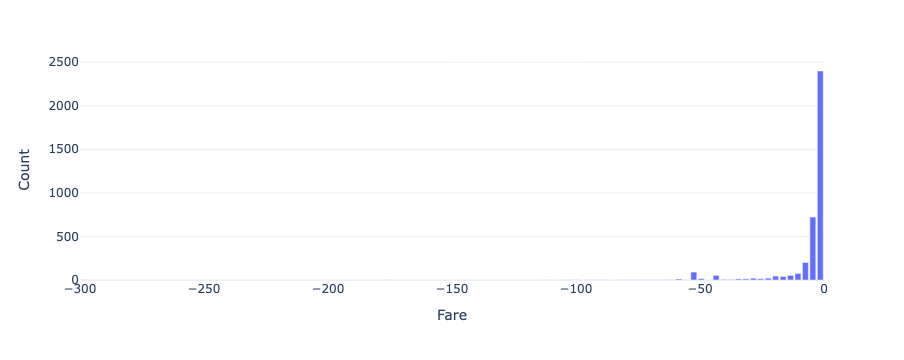

In [29]:
mask = pc.less_equal(col_fare, 0)
hist(col_fare.filter(mask), "Fare", bins=100)

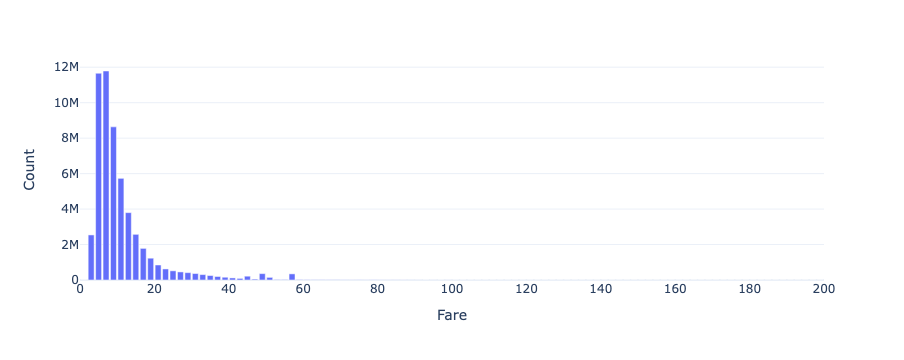

In [30]:
fare_mask = pc.and_(pc.greater(col_fare, 0), 
                    pc.less(col_fare, 200))
hist(col_fare.filter(fare_mask), "Fare", bins=100)

In [31]:
print(pc.sum(pc.greater(col_fare, 60)))
print(pc.sum(pc.greater(col_fare, 100)))
print(pc.sum(pc.greater(col_fare, 200)))

147175
20875
1654


In [32]:
def filter_fare_amount(e: ds.Expression) -> ds.Expression:
    return (e > 1) & (e < 200)

In [33]:
table_filt = data.to_table(
    columns={
        'fare_amount': ds.field('fare_amount').cast(pa.float16()),
    },
    filter=filter_fare_amount(ds.field('fare_amount')),
)
table_filt.shape

(55417333, 1)

In [34]:
sys.getsizeof(table_filt)

110834730

## Pickup datetime

In [35]:
col_pickup = table_full['pickup_datetime']

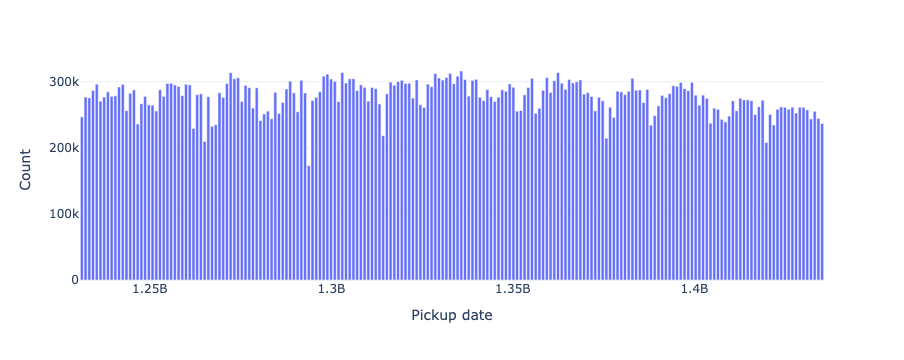

In [36]:
# need to cast datetime to unix timestamp
hist(col_pickup.cast(pa.int64()), "Pickup date", bins=200)

In [37]:
table_filt = data.to_table(
    columns={
        'fare_amount': ds.field('fare_amount').cast(pa.float16()),
        'pickup_datetime': parse_datetime(ds.field('pickup_datetime')),
    },
    filter=filter_fare_amount(ds.field('fare_amount')),
)
table_filt.shape

(55417333, 2)

In [38]:
sys.getsizeof(table_filt)

561102964

## Count of passengers

In [39]:
col_pass = table_full['passenger_count']

In [40]:
pc.value_counts(col_pass).sort()

-- is_valid: all not null
-- child 0 type: uint8
  [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    34,
    49,
    51,
    129,
    208
  ]
-- child 1 type: int64
  [
    195416,
    38337524,
    8175243,
    2432712,
    1178852,
    3929346,
    1174647,
    15,
    9,
    23,
    1,
    1,
    1,
    2,
    64
  ]

In [41]:
table_filt = data.to_table(
    columns={
        'fare_amount': ds.field('fare_amount').cast(pa.float16()),
        'passenger_count': pc.if_else(
            ds.field('passenger_count') == 0, 
            1, ds.field('passenger_count')
        ).cast(pa.uint8()),
        'pickup_datetime': parse_datetime(ds.field('pickup_datetime')),
    },
    filter=filter_fare_amount(ds.field('fare_amount')) & (ds.field("passenger_count") <= 9),
)
table_filt.shape

(55417264, 3)

In [42]:
sys.getsizeof(table_filt)

623449094

## Pickup and dropoff coordinates

In [43]:
col_plon = table_full['pickup_longitude']
col_plat = table_full['pickup_latitude']
col_dlon = table_full['dropoff_longitude']
col_dlat = table_full['dropoff_latitude']

New York coordinates ranges (according to wikipedia):
- Latitude	40° 30′ N to 45° 1′ N
- Longitude	71° 51′ W to 79° 46′ W

## Pickup longitude

In [44]:
vc = pc.value_counts(pc.round(col_plon, ndigits=0))
vc.sort(by=1, order="descending").slice(length=15)

-- is_valid: all not null
-- child 0 type: float
  [
    -74,
    0,
    41,
    -73,
    -75,
    -0,
    -8,
    -1,
    -71,
    -76,
    -72,
    -736,
    -77,
    -4,
    -7
  ]
-- child 1 type: int64
  [
    54299026,
    1057931,
    26718,
    21754,
    6994,
    3994,
    1576,
    1126,
    479,
    447,
    352,
    257,
    215,
    177,
    154
  ]

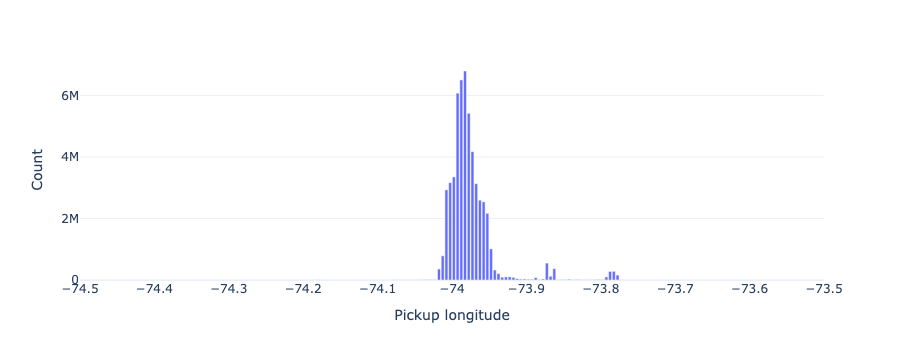

In [45]:
mask = pc.and_(pc.greater(col_plon, -74.5), pc.less(col_plon, -73.5))
hist(col_plon.filter(mask), "Pickup longitude", bins=200)

In [46]:
mask = pc.and_(pc.greater(col_plon, -1), pc.less(col_plon, 1))

vc = pc.value_counts(pc.round(col_plon.filter(mask), ndigits=5))
vc.sort(by=1, order="descending").slice(length=15)

-- is_valid: all not null
-- child 0 type: float
  [
    0,
    -0.11667,
    -0.01667,
    -0.05,
    -0.06667,
    -0.03333,
    -0.08333,
    -0.1,
    -0.15,
    0.00001,
    -0.13333,
    -0.00167,
    0.00003,
    -0.00001,
    0.00002
  ]
-- child 1 type: int64
  [
    1055810,
    392,
    120,
    99,
    81,
    79,
    58,
    58,
    53,
    48,
    46,
    44,
    29,
    27,
    26
  ]

In [47]:
mask = pc.and_(pc.greater(col_plon, -1), pc.less(col_plon, 1))

vc = pc.value_counts(pc.round(col_plat.filter(mask), ndigits=5))
vc.sort(by=1, order="descending").slice(length=15)

-- is_valid: all not null
-- child 0 type: float
  [
    0,
    41.45369,
    0.00002,
    0.00003,
    40.75372,
    40.75,
    0.00004,
    -0.56333,
    0.00006,
    0.00001,
    40.76667,
    40.73333,
    0.00005,
    0.0001,
    0.05
  ]
-- child 1 type: int64
  [
    1052078,
    117,
    54,
    53,
    48,
    42,
    37,
    36,
    34,
    33,
    31,
    29,
    29,
    27,
    26
  ]

In [48]:
mask = pc.and_(pc.greater(col_plon, 40), pc.less(col_plon, 42))
vc = pc.value_counts(pc.round(col_plat.filter(mask), ndigits=1))
vc.sort(by=1, order="descending").slice(length=15)


-- is_valid: all not null
-- child 0 type: float
  [
    -74,
    -73.9,
    -73.8,
    317.6,
    -2145.9,
    -73.7,
    -73.6,
    -74.1,
    -73.5
  ]
-- child 1 type: int64
  [
    24446,
    1695,
    572,
    1,
    1,
    1,
    1,
    1,
    1
  ]

In [49]:
mask = pc.and_(pc.greater(col_plon, -740), pc.less(col_plon, -730))
vc = pc.value_counts(pc.round(col_plon.filter(mask), ndigits=4))
vc.sort(by=1, order="descending").slice(length=15)

-- is_valid: all not null
-- child 0 type: float
  [
    -736.3333,
    -736.5,
    -736.35,
    -736.55,
    -736.1667,
    -736.3666,
    -736.4334,
    -736.5833,
    -736.5166,
    -736.5666,
    -736.3,
    -736.6166,
    -735.1667,
    -736.5334,
    -736.4834
  ]
-- child 1 type: int64
  [
    24,
    21,
    19,
    14,
    14,
    14,
    14,
    13,
    11,
    10,
    10,
    10,
    10,
    10,
    9
  ]

In [50]:
mask = pc.and_(pc.greater(col_plon, -740), pc.less(col_plon, -730))
table_test = table_full.filter(mask)

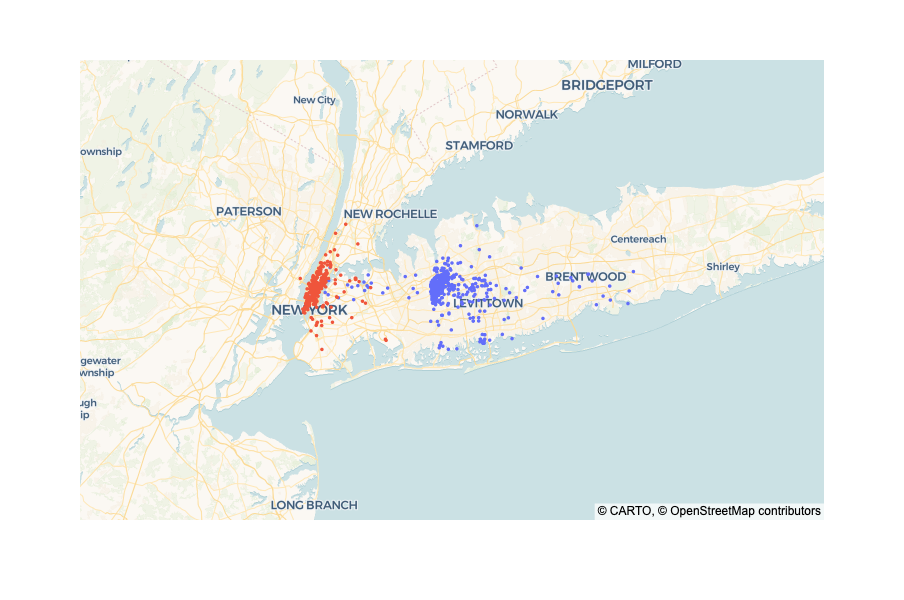

In [51]:
fig = px.scatter_map(
    lat=table_test['pickup_latitude'],
    lon=pc.divide(table_test['pickup_longitude'], 10),
    width=800, height=600,
)
fig.add_trace(
    go.Scattermap(
        lat=table_test['dropoff_latitude'],
        lon=table_test['dropoff_longitude'],
        showlegend=False,
    )
)
fig.update_traces(marker={"size": 4})
fig

## Pickup latitude

In [52]:
vc = pc.value_counts(pc.round(col_plat, ndigits=0))
vc.sort(by=1, order="descending").slice(length=15)

-- is_valid: all not null
-- child 0 type: float
  [
    41,
    0,
    -74,
    40,
    -0,
    42,
    1,
    4,
    39,
    43,
    37,
    45,
    74,
    38,
    5
  ]
-- child 1 type: int64
  [
    54323175,
    1055312,
    26718,
    11418,
    1781,
    963,
    552,
    359,
    338,
    221,
    208,
    203,
    160,
    140,
    138
  ]

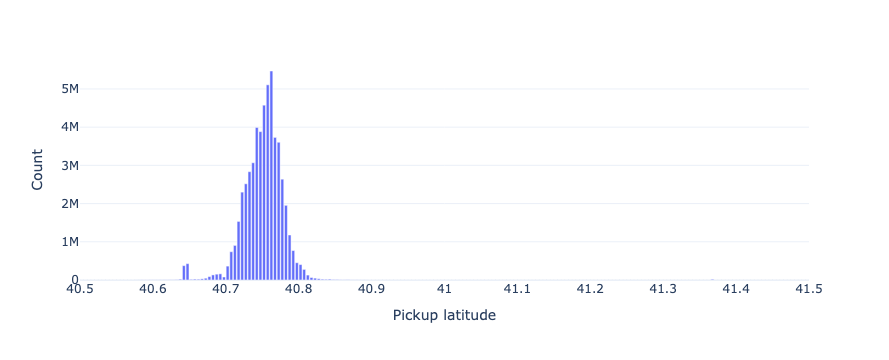

In [53]:
mask = pc.and_(pc.greater(col_plat, 40.5), pc.less(col_plat, 41.5))
hist(col_plat.filter(mask), "Pickup latitude", bins=200)

In [54]:
mask = pc.and_(pc.greater(col_plat, -1), pc.less(col_plat, 1))

vc = pc.value_counts(pc.round(col_plat.filter(mask), ndigits=5))
vc.sort(by=1, order="descending").slice(length=15)

-- is_valid: all not null
-- child 0 type: float
  [
    0,
    0.06667,
    0.66667,
    0.00002,
    0.00003,
    0.05,
    0.00004,
    -0.56333,
    0.00006,
    0.00001,
    0.00005,
    0.0001,
    0.00009,
    0.00008,
    0.1
  ]
-- child 1 type: int64
  [
    1052185,
    93,
    91,
    54,
    53,
    38,
    37,
    36,
    34,
    33,
    29,
    27,
    20,
    18,
    17
  ]

In [55]:
mask = pc.and_(pc.greater(col_plat, -75), pc.less(col_plat, -73))
vc = pc.value_counts(pc.round(col_plon.filter(mask), ndigits=1))
vc.sort(by=1, order="descending").slice(length=15)


-- is_valid: all not null
-- child 0 type: float
  [
    40.8,
    40.7,
    40.6,
    40.9,
    -77.8,
    40.5,
    2130.8
  ]
-- child 1 type: int64
  [
    14357,
    11798,
    548,
    13,
    1,
    1,
    1
  ]

## Dropoff longitude

In [56]:
vc = pc.value_counts(pc.round(col_dlon, ndigits=0))
vc.sort(by=1, order="descending").slice(length=15)

-- is_valid: all not null
-- child 0 type: float
  [
    -74,
    0,
    41,
    -73,
    -75,
    -0,
    -8,
    -1,
    -71,
    -76,
    null,
    -72,
    -736,
    -77,
    -4
  ]
-- child 1 type: int64
  [
    54306220,
    1055011,
    26703,
    19205,
    6189,
    3657,
    1261,
    872,
    441,
    437,
    376,
    339,
    195,
    180,
    157
  ]

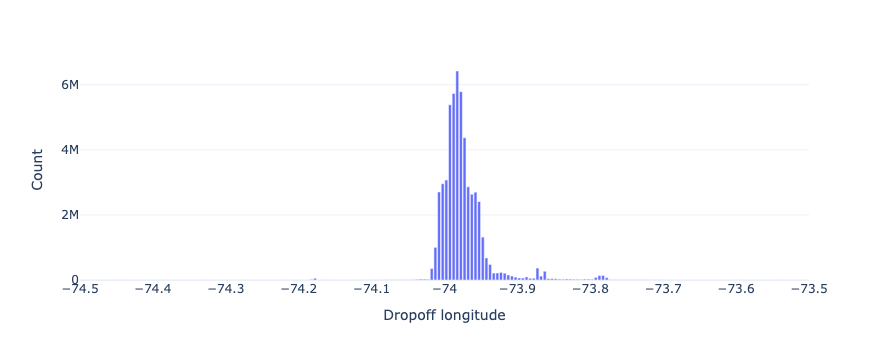

In [57]:
mask = pc.and_(pc.greater(col_dlon, -74.5), pc.less(col_dlon, -73.5))
hist(col_dlon.filter(mask), "Dropoff longitude", bins=200)

In [58]:
mask = pc.and_(pc.greater(col_dlon, -1), pc.less(col_dlon, 1))

vc = pc.value_counts(pc.round(col_dlon.filter(mask), ndigits=5))
vc.sort(by=1, order="descending").slice(length=15)

-- is_valid: all not null
-- child 0 type: float
  [
    0,
    -0.11667,
    -0.01667,
    -0.03333,
    -0.05,
    -0.06667,
    -0.13333,
    0.00001,
    -0.08333,
    -0.1,
    0.00002,
    -0.15,
    -0,
    0.00006,
    0.00003
  ]
-- child 1 type: int64
  [
    1052824,
    282,
    84,
    65,
    56,
    54,
    45,
    40,
    39,
    35,
    32,
    32,
    30,
    19,
    19
  ]

In [59]:
mask = pc.and_(pc.greater(col_dlon, 40), pc.less(col_dlon, 42))
vc = pc.value_counts(pc.round(col_dlat.filter(mask), ndigits=1))
vc.sort(by=1, order="descending").slice(length=15)


-- is_valid: all not null
-- child 0 type: float
  [
    -74,
    -73.9,
    -73.8,
    -74.2,
    -73.7,
    -74.1,
    -73.6,
    317.6,
    -2508,
    -2145.9,
    -73.5,
    -74.4
  ]
-- child 1 type: int64
  [
    23679,
    2541,
    409,
    39,
    18,
    10,
    2,
    1,
    1,
    1,
    1,
    1
  ]

## Dropoff latitude

In [60]:
vc = pc.value_counts(pc.round(col_dlat, ndigits=0))
vc.sort(by=1, order="descending").slice(length=15)

-- is_valid: all not null
-- child 0 type: float
  [
    41,
    0,
    -74,
    40,
    -0,
    42,
    1,
    4,
    null,
    39,
    43,
    45,
    37,
    74,
    405
  ]
-- child 1 type: int64
  [
    54324009,
    1052813,
    26701,
    12959,
    1772,
    932,
    513,
    378,
    376,
    315,
    217,
    206,
    189,
    138,
    123
  ]

## Coordinate transformations

In [61]:
def coord_filter(expr: pc.Expression) -> pc.Expression:
    lon = (expr > -78) & (expr < -70)
    lat = (expr > 36)  & (expr < 46)
    return pc.is_valid(expr) & (lon | lat)

In [62]:
def coord_transform(expr: pc.Expression, swap_min: int, swap_max: int, 
                    swap_expr: pc.Expression) -> pc.Expression:
    return pc.if_else(
        (expr > swap_min) & (expr < swap_max),
        swap_expr, 
        expr
    ).cast(pa.float32())

In [63]:
plon = ds.field('pickup_longitude')
plat = ds.field('pickup_latitude')
dlon = ds.field('dropoff_longitude')
dlat = ds.field('dropoff_latitude')

table_res = data.to_table(
    columns={
        'fare_amount': ds.field('fare_amount').cast(pa.float16()),
        'passenger_count': pc.if_else(
            ds.field('passenger_count') == 0,
            1, ds.field('passenger_count')
        ).cast(pa.uint8()),
        'pickup_datetime': parse_datetime(ds.field('pickup_datetime')),
        'pickup_longitude': coord_transform(plon, 36, 46, plat),
        'pickup_latitude': coord_transform(plat, -79, -70, plon),
        'dropoff_longitude': coord_transform(dlon, 36, 46, dlat),
        'dropoff_latitude': coord_transform(dlat, -79, -70, dlon),
    },
    filter=filter_fare_amount(ds.field('fare_amount')) & \
           (ds.field("passenger_count") <= 9) & \
           coord_filter(plon) & \
           coord_filter(plat) & \
           coord_filter(dlon) & \
           coord_filter(dlat) & \
           (pc.sign(plat) != pc.sign(plon))
)
print(table_res.shape)
print(sys.getsizeof(table_res))

(54293690, 7)
1506664366


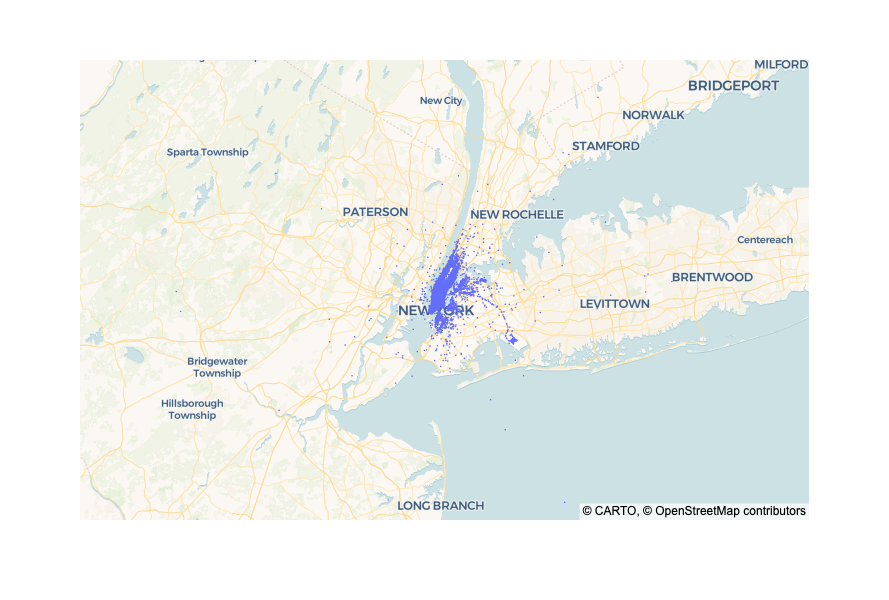

In [64]:
coords = table_res.slice(length=50000)
fig = px.scatter_map(
    lat=coords['pickup_latitude'],
    lon=coords['pickup_longitude'],
    width=800, height=600,
)
fig.update_traces(marker={"size": 2})

# Index column

In [65]:
def add_index_column(table: pa.Table) -> pa.Table:
    col = pa.array(range(table.shape[0]), type=pa.uint32())
    return table.add_column(0, "idx", col)

In [66]:
table_res = add_index_column(table_res)
table_res.schema

idx: uint32
fare_amount: halffloat
passenger_count: uint8
pickup_datetime: timestamp[s]
pickup_longitude: float
pickup_latitude: float
dropoff_longitude: float
dropoff_latitude: float

In [67]:
sys.getsizeof(table_full)

1615138057

# The logic above in lib

In [68]:
import data

In [69]:
dataset = data.get_dataset()
table_full = data.get_cleaned_table(dataset)
table_full.schema

idx: uint32
fare_amount: halffloat
passenger_count: uint8
pickup_datetime: timestamp[s]
pickup_longitude: float
pickup_latitude: float
dropoff_longitude: float
dropoff_latitude: float

In [70]:
table_full.shape

(54293690, 8)